In [139]:
%pip install pandas

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [140]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip3.12 install --upgrade pip


In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [142]:
%matplotlib inline

In [143]:
df = pd.read_csv('/Users/ritasun/Desktop/data use/train.csv')
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [144]:
chunker = pd.read_csv('/Users/ritasun/Desktop/data use/train.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [145]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

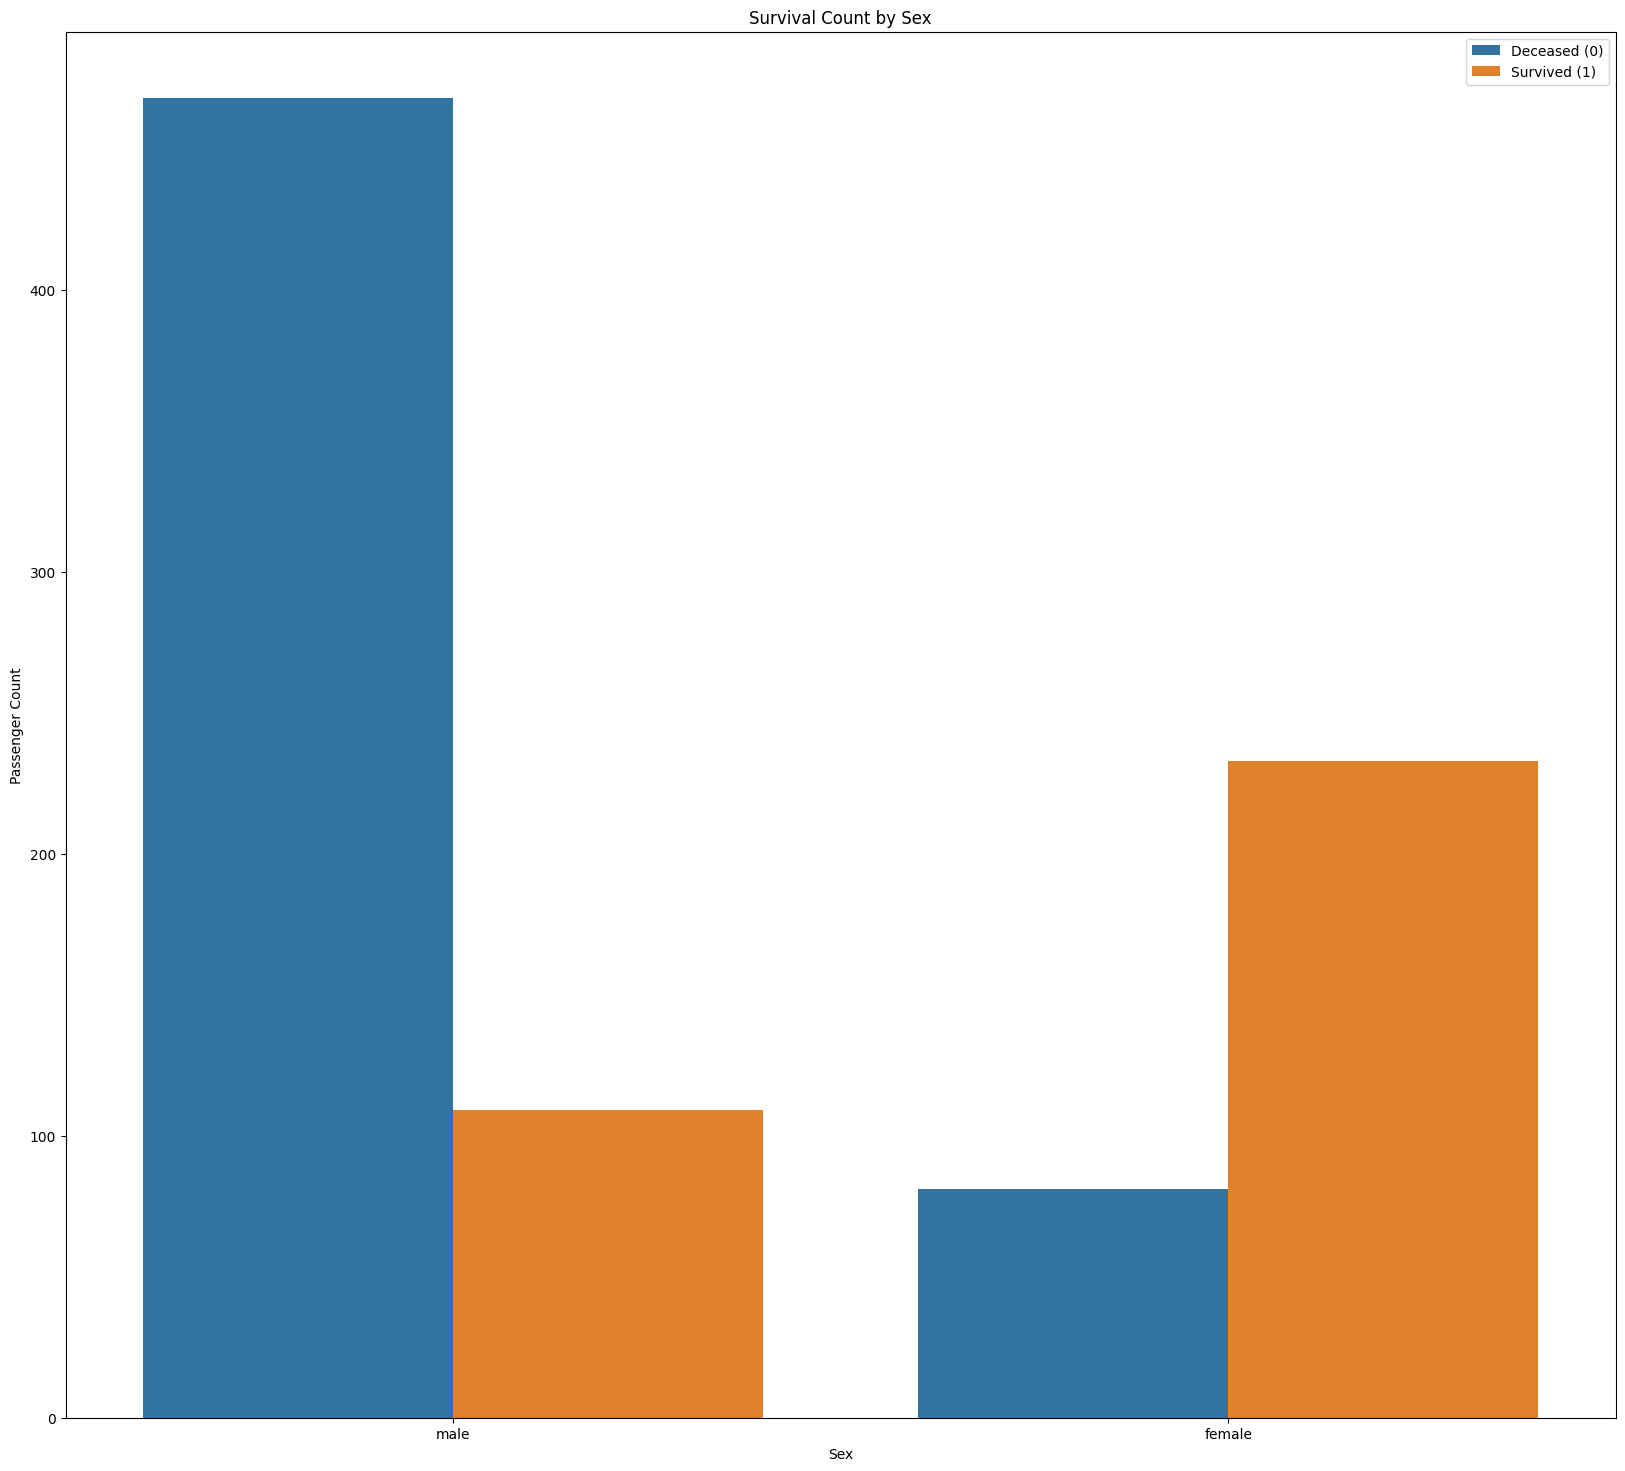

In [146]:
plt.figure(figsize=(20, 18))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Count by Sex')
plt.xlabel('Sex')
plt.ylabel('Passenger Count')

plt.legend(['Deceased (0)', 'Survived (1)'])
plt.show()

<Figure size 2000x1800 with 0 Axes>

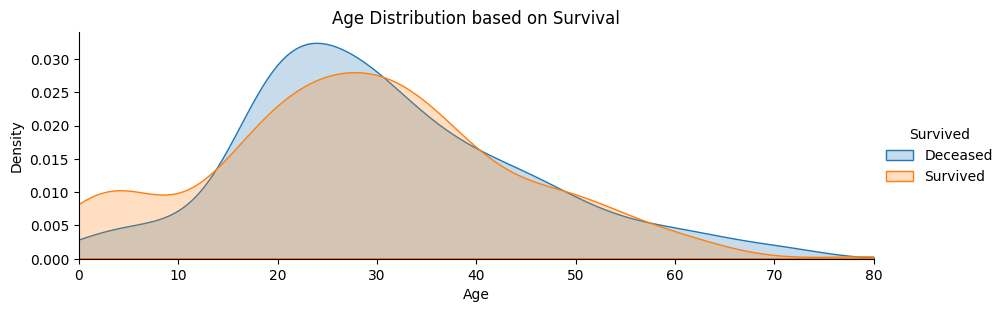

In [147]:
plt.figure(figsize=(20, 18))
facet = sns.FacetGrid(df, hue="Survived", aspect=3)
facet.map(sns.kdeplot, 'Age', fill=True)

facet.set(xlim=(0, df['Age'].max()))
facet.add_legend(labels=['Deceased', 'Survived'])
plt.title('Age Distribution based on Survival')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

### Data analytical insights
#### 1. Rationale for investigation objectives:
##### The primary object of this EDA project is to understand the underlying patterns which determined a passenger's fate during Titanic disaster. The study strategically selects 'Sex', 'Pclass', and 'Age' as core target features. These columns represent socio economic status, physical vulnerability and demographic identity.
#### 2. Comprehensive findings
##### Gender based survival dynamics: The graph shows a massive disparity between female and male survival rates. Even though males made up the majority of the ship's population, the death rate was high. In contrast, more female passengers were saved. The result confirms that gender based rescue prioritization was enforced during evacuation.


##### The impact of social class: The second chart examines that 'Pclass' represents wealth and cabin location of the passengers, which demonstrate a relationship between social class and survival probability. As the chart shown, first class passengers have the higher survival rate,due to their cabins are located closer to lifeboards. In contrast, third class passengers suffered the most and gets the highest death rate.


##### Age distribution: The plot chart shows a sharp peak in survival for children aged 0 to 10 years old, while young adults (age 20-30) shows a massive death rate, who made up the largest group on the ship.


#### Conclusion
##### The EDA demonstrates the surviving rate of Titanic was largely decided by institutional rescur rules and social class.

## Week2

In [148]:
df_week2 = df.copy()

df_week2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [149]:
df_week2.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

In [150]:
df_week2['HasCabin'] = df_week2['Cabin'].notnull().astype(int)

In [151]:
df_week2['Age'] = df_week2['Age'].fillna(df_week2['Age'].median())

In [152]:
df_week2['Embarked'] = df_week2['Embarked'].fillna(df_week2['Embarked'].mode()[0])

df_week2['Cabin'] = df_week2['Cabin'].fillna('Unknown')


In [153]:
df_week2.isnull().sum().sort_values(ascending=False)

Cabin          687
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
HasCabin         0
dtype: int64

In [154]:
df_week2['Pclass'] = df_week2['Pclass'].astype('category')
df_week2['Sex'] = df_week2['Sex'].astype('category')
df_week2['Embarked'] = df_week2['Embarked'].astype('category')

In [155]:
df_week2.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    category
 3   Name         891 non-null    str     
 4   Sex          891 non-null    category
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    str     
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    str     
 11  Embarked     891 non-null    category
 12  HasCabin     891 non-null    int64   
dtypes: category(3), float64(2), int64(5), str(3)
memory usage: 72.4 KB


In [156]:
df_week2['FamilySize'] = df_week2['SibSp'] + df_week2['Parch'] + 1

df_week2['IsAlone'] = (df_week2['FamilySize'] == 1).astype(int)

df_week2[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


In [157]:
df_week2['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

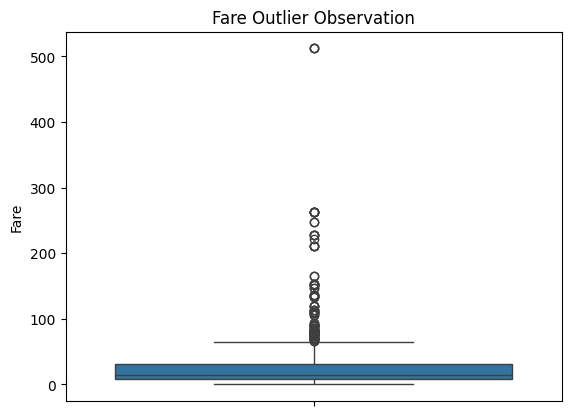

In [158]:
sns.boxplot(y=df_week2['Fare'])
plt.title('Fare Outlier Observation')
plt.ylabel('Fare')
plt.show()

In [159]:
df_week2.sort_values('Fare', ascending=False)[
    ['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked']
].head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked
258,259,1,1,female,35.0,512.3292,C
737,738,1,1,male,35.0,512.3292,C
679,680,1,1,male,36.0,512.3292,C
88,89,1,1,female,23.0,263.0000,S
27,28,0,1,male,19.0,263.0000,S


## 5 Questions
#### 1. Category with the most passenger

In [160]:
df_week2['Sex'].value_counts()

df_week2['Pclass'].value_counts()

df_week2['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

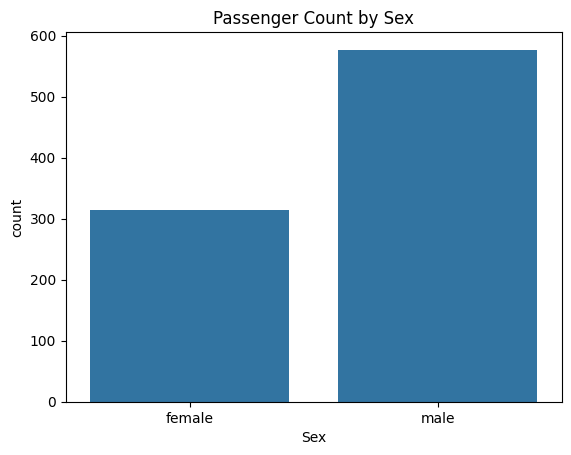

In [161]:
sns.countplot(x='Sex', data=df_week2)
plt.title('Passenger Count by Sex')
plt.show()

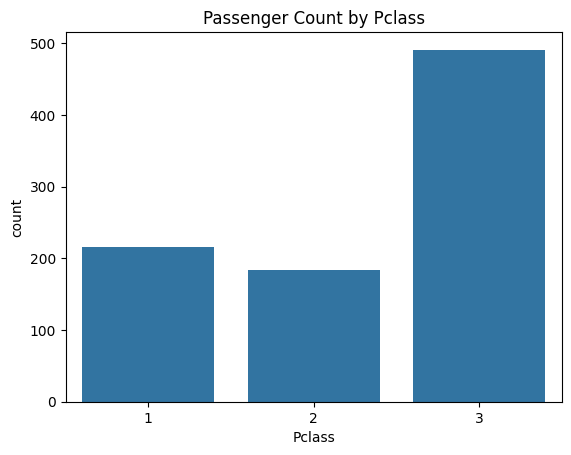

In [162]:
sns.countplot(x='Pclass', data=df_week2)
plt.title('Passenger Count by Pclass')
plt.show()

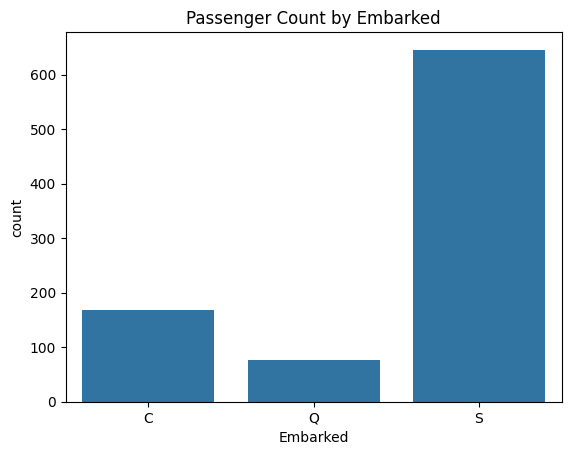

In [163]:
sns.countplot(x='Embarked', data=df_week2)
plt.title('Passenger Count by Embarked')
plt.show()

##### Explanation
##### After checking the distribution of 'Sex', 'Pclass' and 'Embarked', the data shows that there are more males than females. In this case, third class passengers made up a large part of dataset. For Embarked, most passengers boarded from port S.

#### 2. Survival rate by sex.

In [164]:
df_week2.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

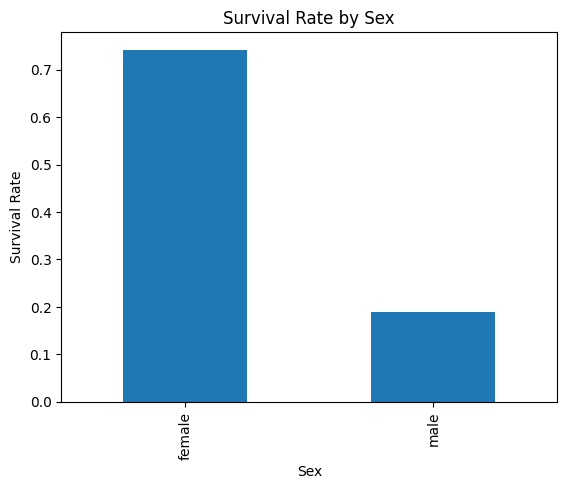

In [165]:
df_week2.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.show()

##### Explanation:
##### The result shows that female passengers had a higher survival rate than male passengers. This suggests that gender may be related to survival in the Titanic dataset.

#### 3. Survival rate by Pclass 

In [166]:
df_week2.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

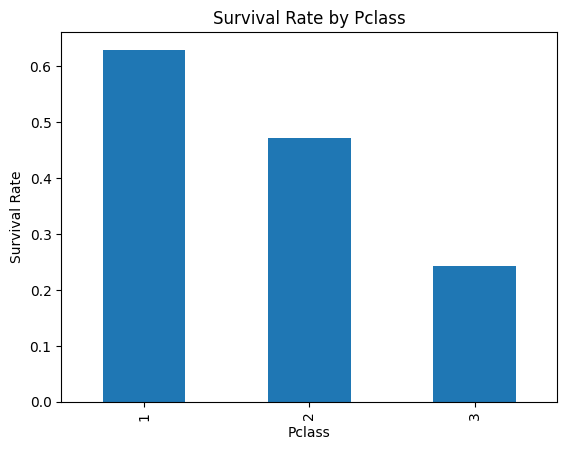

In [167]:
df_week2.groupby('Pclass')['Survived'].mean().plot(kind='bar')
plt.title('Survival Rate by Pclass')
plt.xlabel('Pclass')
plt.ylabel('Survival Rate')
plt.show()

##### Explanation
##### The result shows that first class passengers had a higher survival rate than third class passengers. This means passenger class may be an important factor related to survival.

#### 4. Survival rate by family size

In [169]:
df_week2.groupby('FamilySize')['Survived'].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

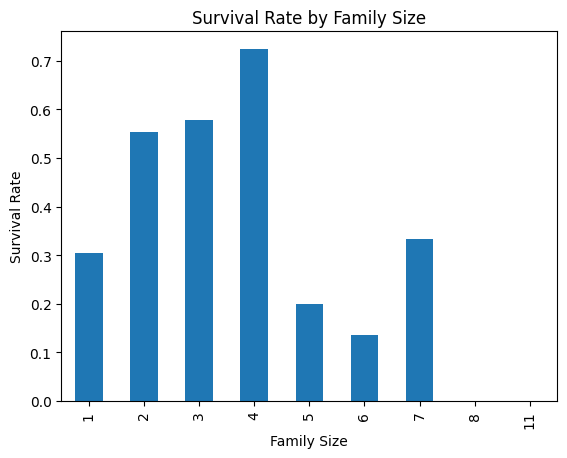

In [170]:
df_week2.groupby('FamilySize')['Survived'].mean().plot(kind='bar')
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.show()

##### Explanation
##### As the graph shows, family size with 4 people has the most survival rate, in comparison, family size with 6 people has the least survival rate.

#### 5. Does boarding alone affect the survival rate?


In [171]:
df_week2.groupby('IsAlone')['Survived'].mean()

IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64

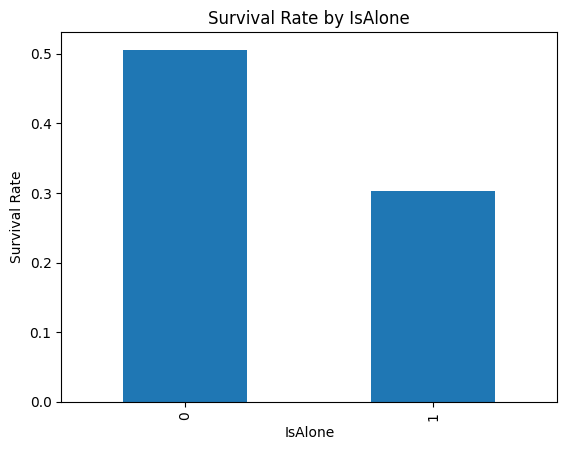

In [172]:
df_week2.groupby('IsAlone')['Survived'].mean().plot(kind='bar')
plt.title('Survival Rate by IsAlone')
plt.xlabel('IsAlone')
plt.ylabel('Survival Rate')
plt.show()

##### Explanation
##### The survival rate for passengers who boarded alone was lower.

In [173]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [174]:
model_data = df_week2.copy()

In [175]:
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'HasCabin']

In [176]:
X = model_data[features]

y = model_data['Survived']

In [177]:
X = pd.get_dummies(X)

In [183]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=100
)


In [184]:
model = LogisticRegression(max_iter=1000)

In [185]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [186]:
y_pred = model.predict(X_test)

In [187]:
accuracy_score(y_test, y_pred)

0.7988826815642458

### Final summary

##### The goal of week 2 is to move from basic data preview to deeper data analysis from week 1.  The first was to check missing values. The main columns with missing values were Age, Cabin, and Embarked. Since age is a numerical variable, the missing values were filled with median age. Embarked is classifed as a categorical variable, so the missing values were filled wih the most common value. Since there were a lot of missing values for Cabin, a new variable called HasCabin was created and use to show whether a passenger had cabin information. And the missing value in Cabin were filled with unknown.

##### After that, groups not including numerical values such as  Pclass, Sex and Embarked were converted into category type. Two new variables, familysize represents the total number of family members on board, and isalone show whether the passenger traveld alone.

##### Several business questions were explored in this notebook. The results showed that female passengers had a higher survival rate than male passengers. First-class passengers also had a higher survival rate than third-class passengers. In addition, passengers who traveled alone had a lower survival rate than passengers who traveled with family.

##### Finally, a simple logistic regression model was built using scikit-learn. The model used Pclass, Sex, Age, Fare, Embarked, FamilySize, IsAlone, and HasCabin to predict whether a passenger survived. 